In [167]:
#setup 

import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid
from torchvision.datasets import FashionMNIST
import os

if not os.path.exists('./dc_img'):
    os.mkdir('./dc_img')
    
print ("setup done")

setup done


In [168]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

In [169]:
#hyperparameters
num_epochs = 10 #each epoch has a runtime of approx. 4 min
batch_size = 128
learning_rate = 1e-3

markdown the data set cell that will not be used.
user must set USE_XRAY_VAL in Xray data set to true or false depeinding on if the run is for train or validation

In [ ]:
#Fashion MINST Data loading and data set
USE_XRAY_VAL = False #validation is only for xray data set. the losses seen on fashion minst during training were low (1st run 1st epoch was 0.04) so some training can be considered sufficent with no need for vlaidation. unlike Xray where loss was higher initally so need a metric to stop training.
img_transform = transforms.Compose([
    transforms.Resize((128, 128)), #we want the input images of both FashionMINST and xray to be of same size so that model can work on both. we are using transpose convelution in recostruction so the output size must be equal ti input size in order to compute the loss. hence standarize both datasets to same size
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])
dataset = FashionMNIST('./FashionMNIST', train=True, transform=img_transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Number of batches:", len(dataloader))




Number of batches: 469


In [155]:
#Chest xray data loading and data set
USE_XRAY_VAL = False
img_transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.Grayscale(num_output_channels=1),  # ensure 1 channel like FashionMINST
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
if not USE_XRAY_VAL:
    dataset = datasets.ImageFolder('./chest_xray/train', transform=img_transform)
    print("using training data for training ")
if USE_XRAY_VAL:
    val_dataset = datasets.ImageFolder('./chest_xray/val', transform=img_transform)
    print("using validation data for validation ")
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print("Number of batches:", len(dataloader))

using training data for training 
Number of batches: 41


In [171]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [172]:
#Model definition
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 5, stride=1, padding=2),  #to maintain spatial zise of output same as input. output 16x128x128
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),  #16x64x64
            nn.Conv2d(16, 8, 5, stride=1, padding=2),  #8x64x64
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2)  #8x32X32
            
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(8, 16, 2, stride=2),  #16x64x64
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 2, stride=2),  #8x128x128
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=1, padding=1),  #1x128x128
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

print ("model defined")


model defined


In [173]:
#Model and optimizer
model = autoencoder()

# load model if exists, after finalizing on the model, this can be used.
if os.path.exists("conv_autoencoder.pth"):
    model.load_state_dict(torch.load("conv_autoencoder.pth"))
    print("Loaded previous model weights")
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                             weight_decay=1e-5)

In [174]:
#detect the last run number from dc_img folder so that images saved in it are based on run number and repective epoch within the run.
save_path = "./dc_img"

existing_files = os.listdir(save_path)

run_ids = []

for f in existing_files:
    if "run" in f:
        try:
            run_num = int(f.split("run")[1].split("_")[0])
            run_ids.append(run_num)
        except:
            pass

run_id = max(run_ids) + 1 if run_ids else 1

print(f"Starting Run {run_id}")

Starting Run 1


In [175]:
#save locally a grid of size 9X8 where first 3 rows are original images, later 3 rows are their respective noisy versions, later 3 rows are their respective reconstruced versions
#images are randomly selected from same batch
def save_comparison_grid(img, noisy_img, output, epoch, save_path="./dc_img"):
    
    num_cols = 8
    num_imgs = num_cols * 3   #24 images → 3 rows per category

    #random selection (same indices for all 3 types)
    indices = torch.randperm(img.size(0))[:num_imgs]

    orig_imgs = img[indices]
    noisy_imgs = noisy_img[indices]
    recon_imgs = output[indices]

    #convert to [0,1]
    orig_imgs = to_img(orig_imgs)
    noisy_imgs = to_img(noisy_imgs)
    recon_imgs = to_img(recon_imgs)

    #stack: orig below it is noisy below it is recon
    grid_imgs = torch.cat([orig_imgs, noisy_imgs, recon_imgs], dim=0)

    #create grid
    grid = make_grid(grid_imgs, nrow=num_cols)

    #save
    if not USE_XRAY_VAL:
        save_image(grid, f"{save_path}/grid_run{run_id}_epoch_{epoch}.png")
    if USE_XRAY_VAL:
        save_image(grid, f"{save_path}/validation{run_id}.png") 
    return grid

In [176]:
#saving the loss of cuurrent run so that in next run it gets appended to the new loss in the loss curve in order to show a representative learning flow
train_loss_file = "losses.pt"
val_loss_file = "val_losses.pt"
#load train losses
if os.path.exists(train_loss_file):
    losses = torch.load(train_loss_file)
    print(f"Loaded previous losses: {len(losses)} points")
else:
    losses = [] 
# Load validation losses 
if os.path.exists(val_loss_file):
    val_losses = torch.load(val_loss_file)
    print(f"Loaded val losses: {len(val_losses)} points")
else:
    val_losses = []

Training 
Epoch [1/10], Loss: 0.0400


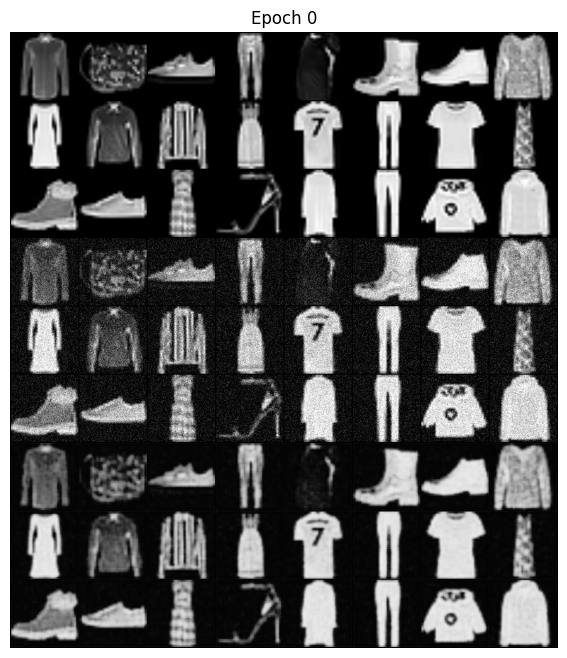

Epoch [2/10], Loss: 0.0054
Epoch [3/10], Loss: 0.0043
Epoch [4/10], Loss: 0.0036
Epoch [5/10], Loss: 0.0031
Epoch [6/10], Loss: 0.0027
Epoch [7/10], Loss: 0.0026
Epoch [8/10], Loss: 0.0025
Epoch [9/10], Loss: 0.0023
Epoch [10/10], Loss: 0.0023


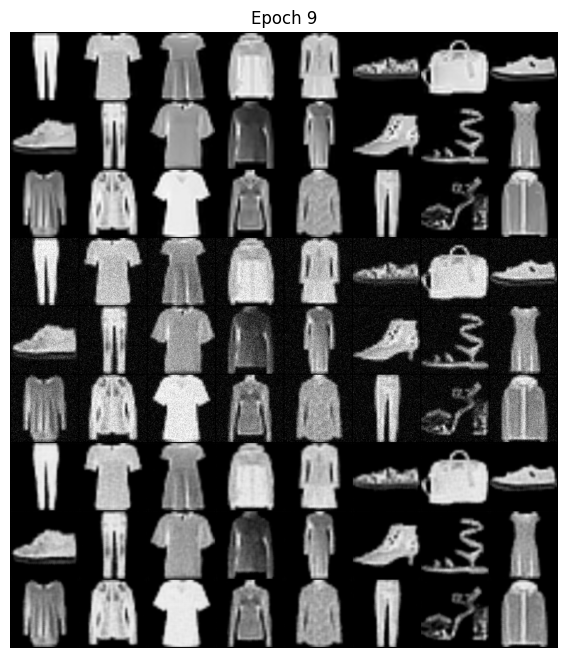

In [177]:
#Training loop
if not USE_XRAY_VAL:
    print("Training ")
    for epoch in range(num_epochs):
        total_loss = 0
        for data in dataloader:
            img, _ = data
            img = Variable(img)
            sigma = random.choice([0.1, 0.2, 0.3])
            noisy_img = add_noise(img, sigma=sigma)
            # ===================forward=====================
            output = model(noisy_img)
            loss = criterion(output, img)
            # ===================backward====================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        # ===================log========================
        
        avg_loss = total_loss / len(dataloader) #avergae loss per epoch
        losses.append(avg_loss) #store average loss per epoch for plotting later
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}") #print the avg loss for each epoch
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            grid = save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images every 10 epochs
            plt.figure(figsize=(8,8))
            plt.imshow(grid.permute(1, 2, 0))
            plt.title(f"Epoch {epoch}")
            plt.axis('off')
            plt.show()
            

In [178]:
#Validation loop
if USE_XRAY_VAL:
    print("Validating")
    total_val_loss = 0

    model.eval()  # evaluation mode which does batch normalization and dropout as per testing/val phase

    for data in dataloader:
        img, _ = data
        img = Variable(img)
        sigma = random.choice([0.1, 0.2, 0.3])
        noisy_img = add_noise(img, sigma=sigma)

        #forward pass only
        with torch.no_grad():
            output = model(noisy_img)
            loss = criterion(output, img)

        total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(dataloader)
    val_losses.append(avg_val_loss)

    print(f"Validation Loss (1 epoch): {avg_val_loss:.4f}")
    grid = save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images
    plt.figure(figsize=(8,8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f"validation{run_id}")
    plt.axis('off')
    plt.show()
    model.train()  # switch back to training mode

else:
    print("Skipping validation")

Skipping validation


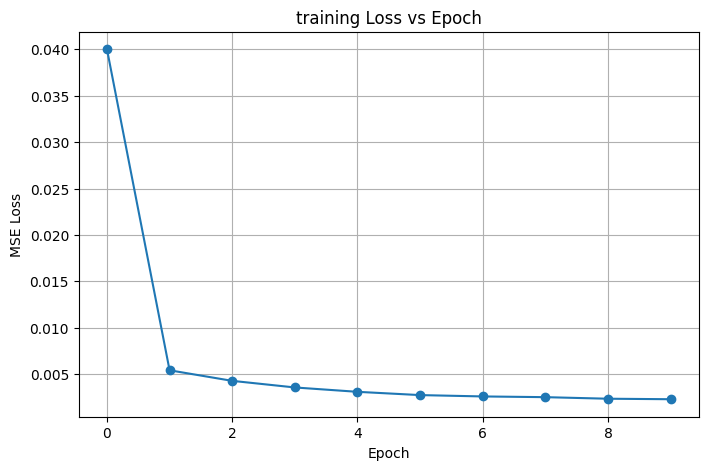

In [179]:
#plotting the trainloss curve
if not USE_XRAY_VAL:
    plt.figure(figsize=(8,5))
    plt.plot(losses, marker='o')
    plt.title("training Loss vs Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.grid(True)
    plt.show()

In [180]:
if USE_XRAY_VAL:
    plt.figure(figsize=(8,5))
    plt.plot(val_losses, marker='o')
    plt.title("val Loss vs val Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.grid(True)
    plt.show()

In [181]:
#save model
if not USE_XRAY_VAL:
    torch.save(model.state_dict(), './conv_autoencoder.pth')
    print("Saved updated model weights")
    #save losses
    torch.save(losses, train_loss_file)
    print("Saved updated loss history")
if USE_XRAY_VAL:
    torch.save(val_losses, val_loss_file)
    print("Saved updated val_loss history")

Saved updated model weights
Saved updated loss history
